# DD CrB O-C Modeling
This notebook demonstrates O-C modeling for DD CrB.

In [3]:
%load_ext autoreload
%autoreload 2
import os
os.environ['PYTENSOR_FLAGS'] = 'mode=NUMBA'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from ocpy.data import Data

column_mapping = {
    "BJD Min": "minimum_time",
    "Err": "minimum_time_error",
    "Type": "minimum_type",
    "obs type": "labels"
}

data = Data.from_file("DD_CrB_Minima.xlsx", columns=column_mapping)
data = data.fill_errors(0.0001).calculate_weights()

t0 = 2455611.92657
period = 0.161770446

oc = data.calculate_oc(
    reference_minimum=t0,
    reference_period=period,
    model_type="pymc"
)
print("Data:", data)
print("OC:", oc)

Data:      minimum_time  minimum_time_error       weights minimum_type      labels
0    2.454532e+06            0.000015  4.444444e+09            p  Literature
1    2.454533e+06            0.000015  4.444444e+09            p  Literature
2    2.454536e+06            0.000015  4.444444e+09            p  Literature
3    2.454537e+06            0.000015  4.444444e+09            p  Literature
4    2.454555e+06            0.000015  4.444444e+09            p  Literature
..            ...                 ...           ...          ...         ...
474  2.460740e+06            0.000029  1.167229e+09            p    Ždánice 
475  2.460460e+06            0.000028  1.275510e+09            p    Ždánice 
476  2.460069e+06            0.000014  5.102041e+09            p    Ždánice 
477  2.460057e+06            0.000003  1.111111e+11            p    Ždánice 
478  2.460461e+06            0.000003  1.111111e+11            p    Ždánice 

[479 rows x 5 columns]
OC:      minimum_time  minimum_time_error     

<Axes: ylabel='O−C'>

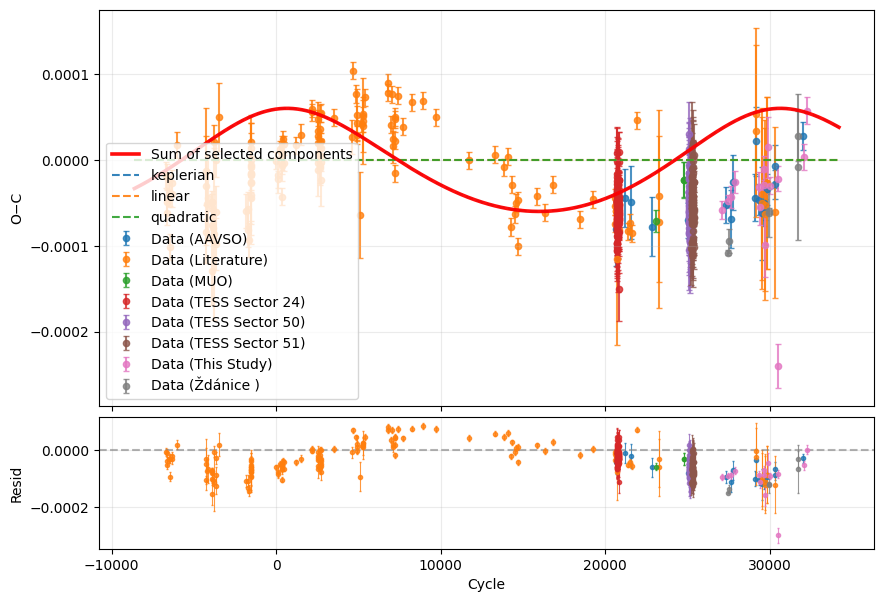

In [5]:
from ocpy.oc import Keplerian, Linear, Quadratic, Parameter

kep = Keplerian(
    amp=Parameter(value=6e-05, std=4e-5, min=0.0, max=1e-4, fixed=False),
    e=Parameter(value=.2, std=.1, min=0.0, max=0.95, fixed=False),
    omega=Parameter(value=8e+01, std=180, min=0.0, max=360.0, fixed=False),
    P=Parameter(value=3e+04, std=10000, min=10000, fixed=False),
    T0=Parameter(value=3e+04, std=30000, fixed=False)
)
lin = Linear(
    a=Parameter(value=0, std=1e-9, min=-1e-9, fixed=False),
    b=Parameter(value=0, std=1e-4, min=-1e-4, fixed=False)
)
quad = Quadratic(
    q=Parameter(value=0, std=1e-9, min=-1e-9, fixed=False)
)
models = [kep, lin, quad]
oc.plot(models)

In [6]:
res = oc.fit(
    models, 
    tune=2000,
    draws=2000, 
    chains=4,
    target_accept=0.95,
    progressbar=True,
    init="adapt_diag"
)

Initializing NUTS using adapt_diag...
c:\Users\bar1s\miniconda3\envs\ocpy\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [keplerian_amp, keplerian_e, keplerian_omega, keplerian_P, keplerian_T0, linear_a, linear_b, quadratic_q]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 351 seconds.


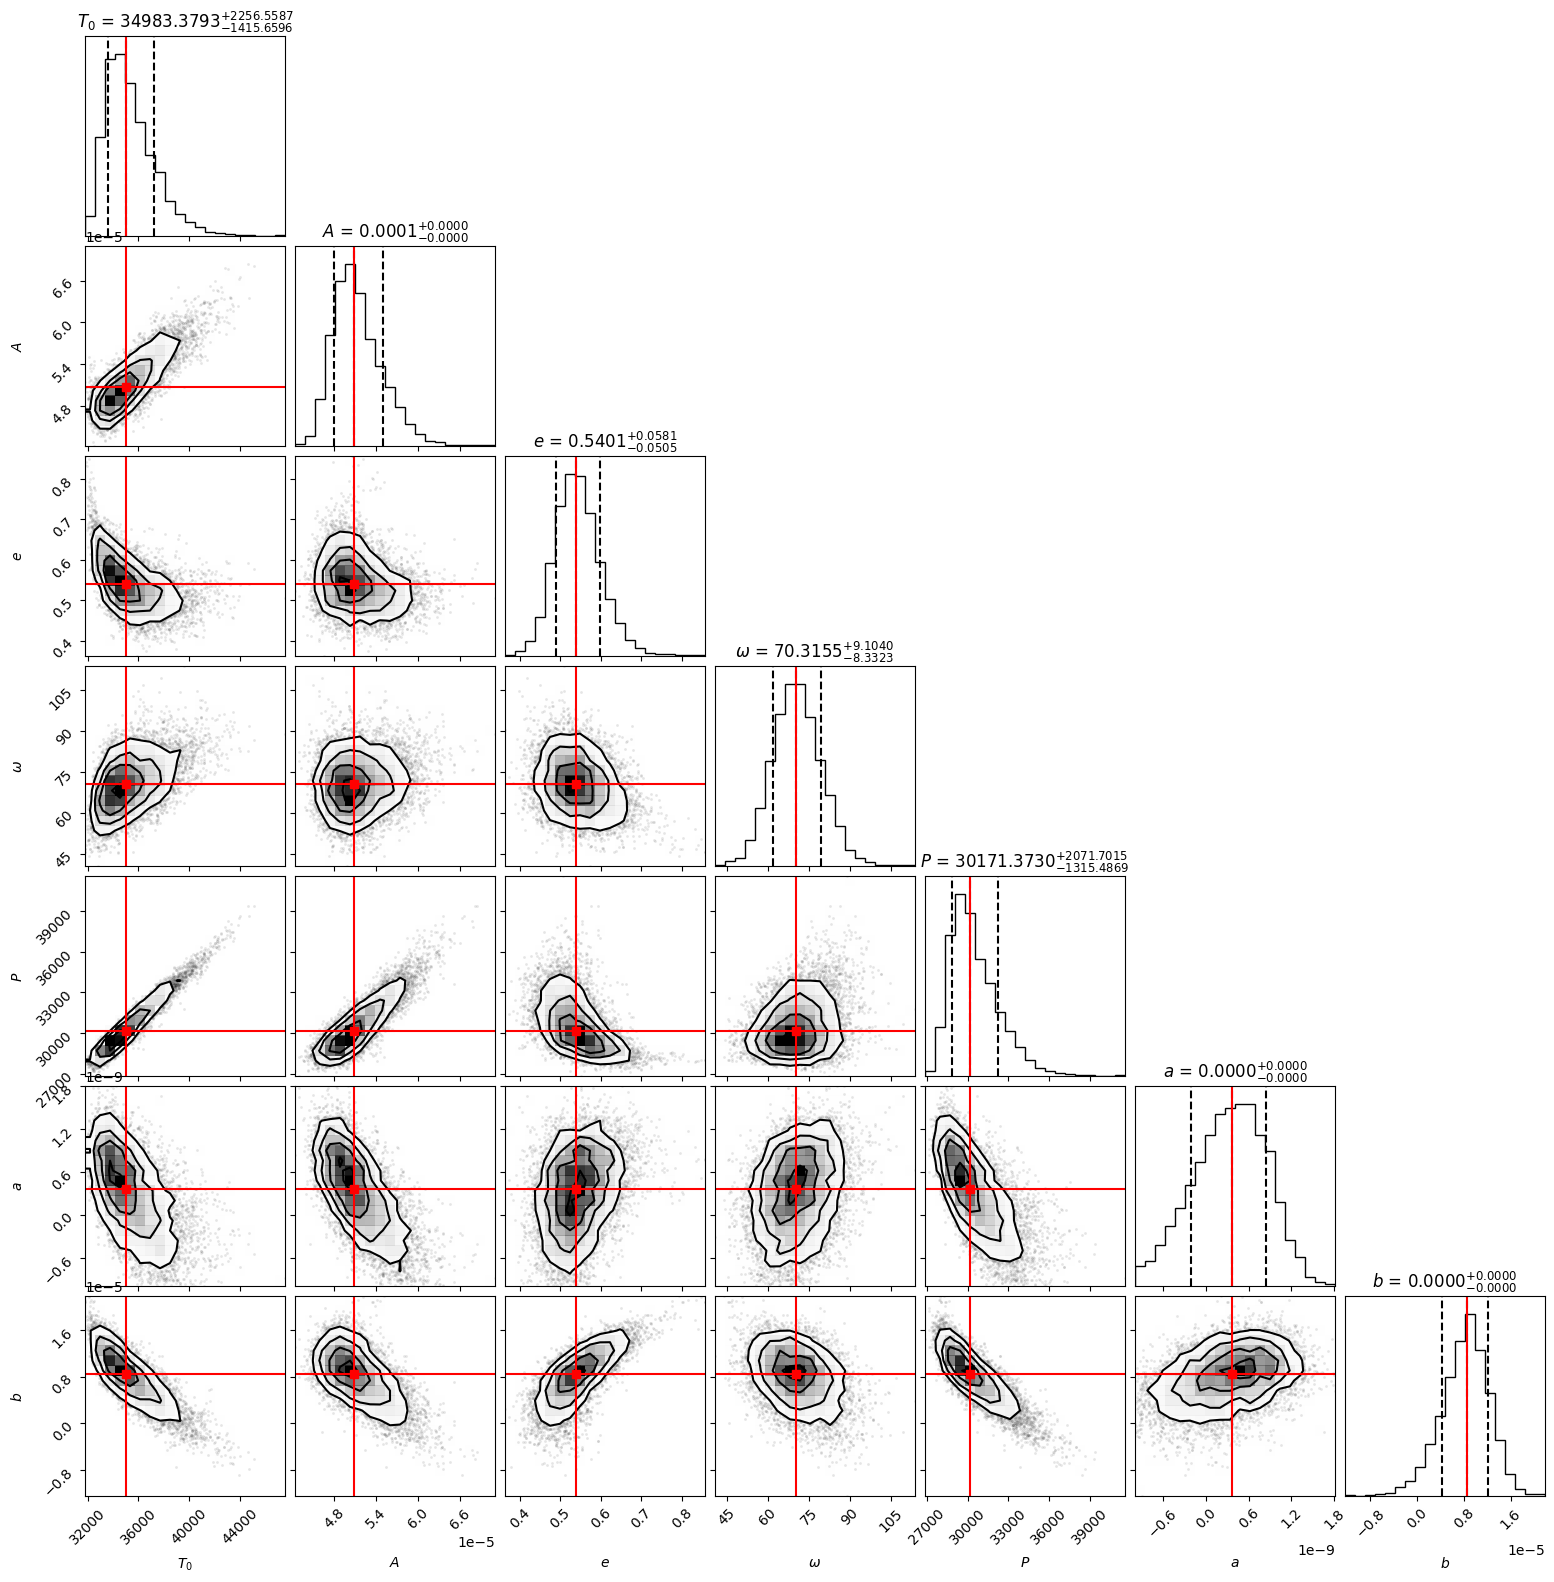

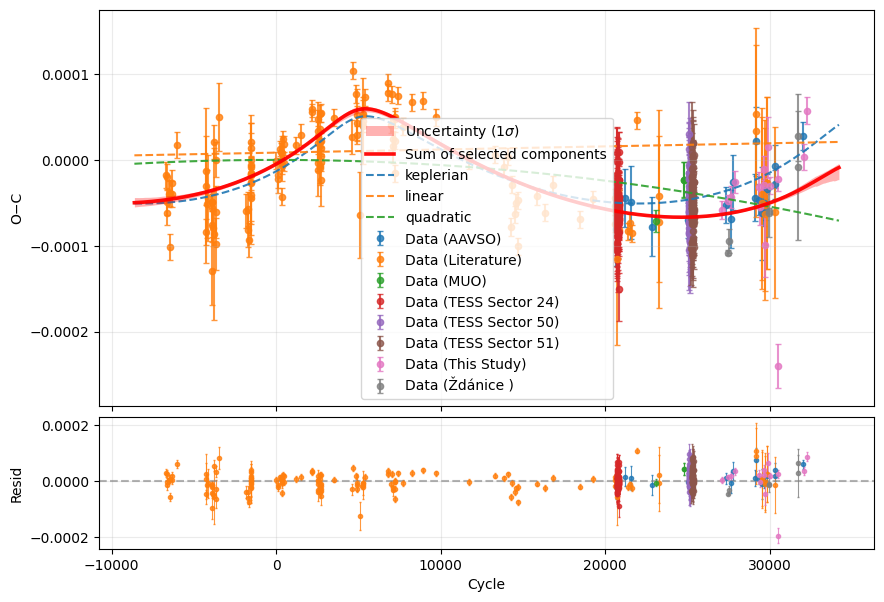

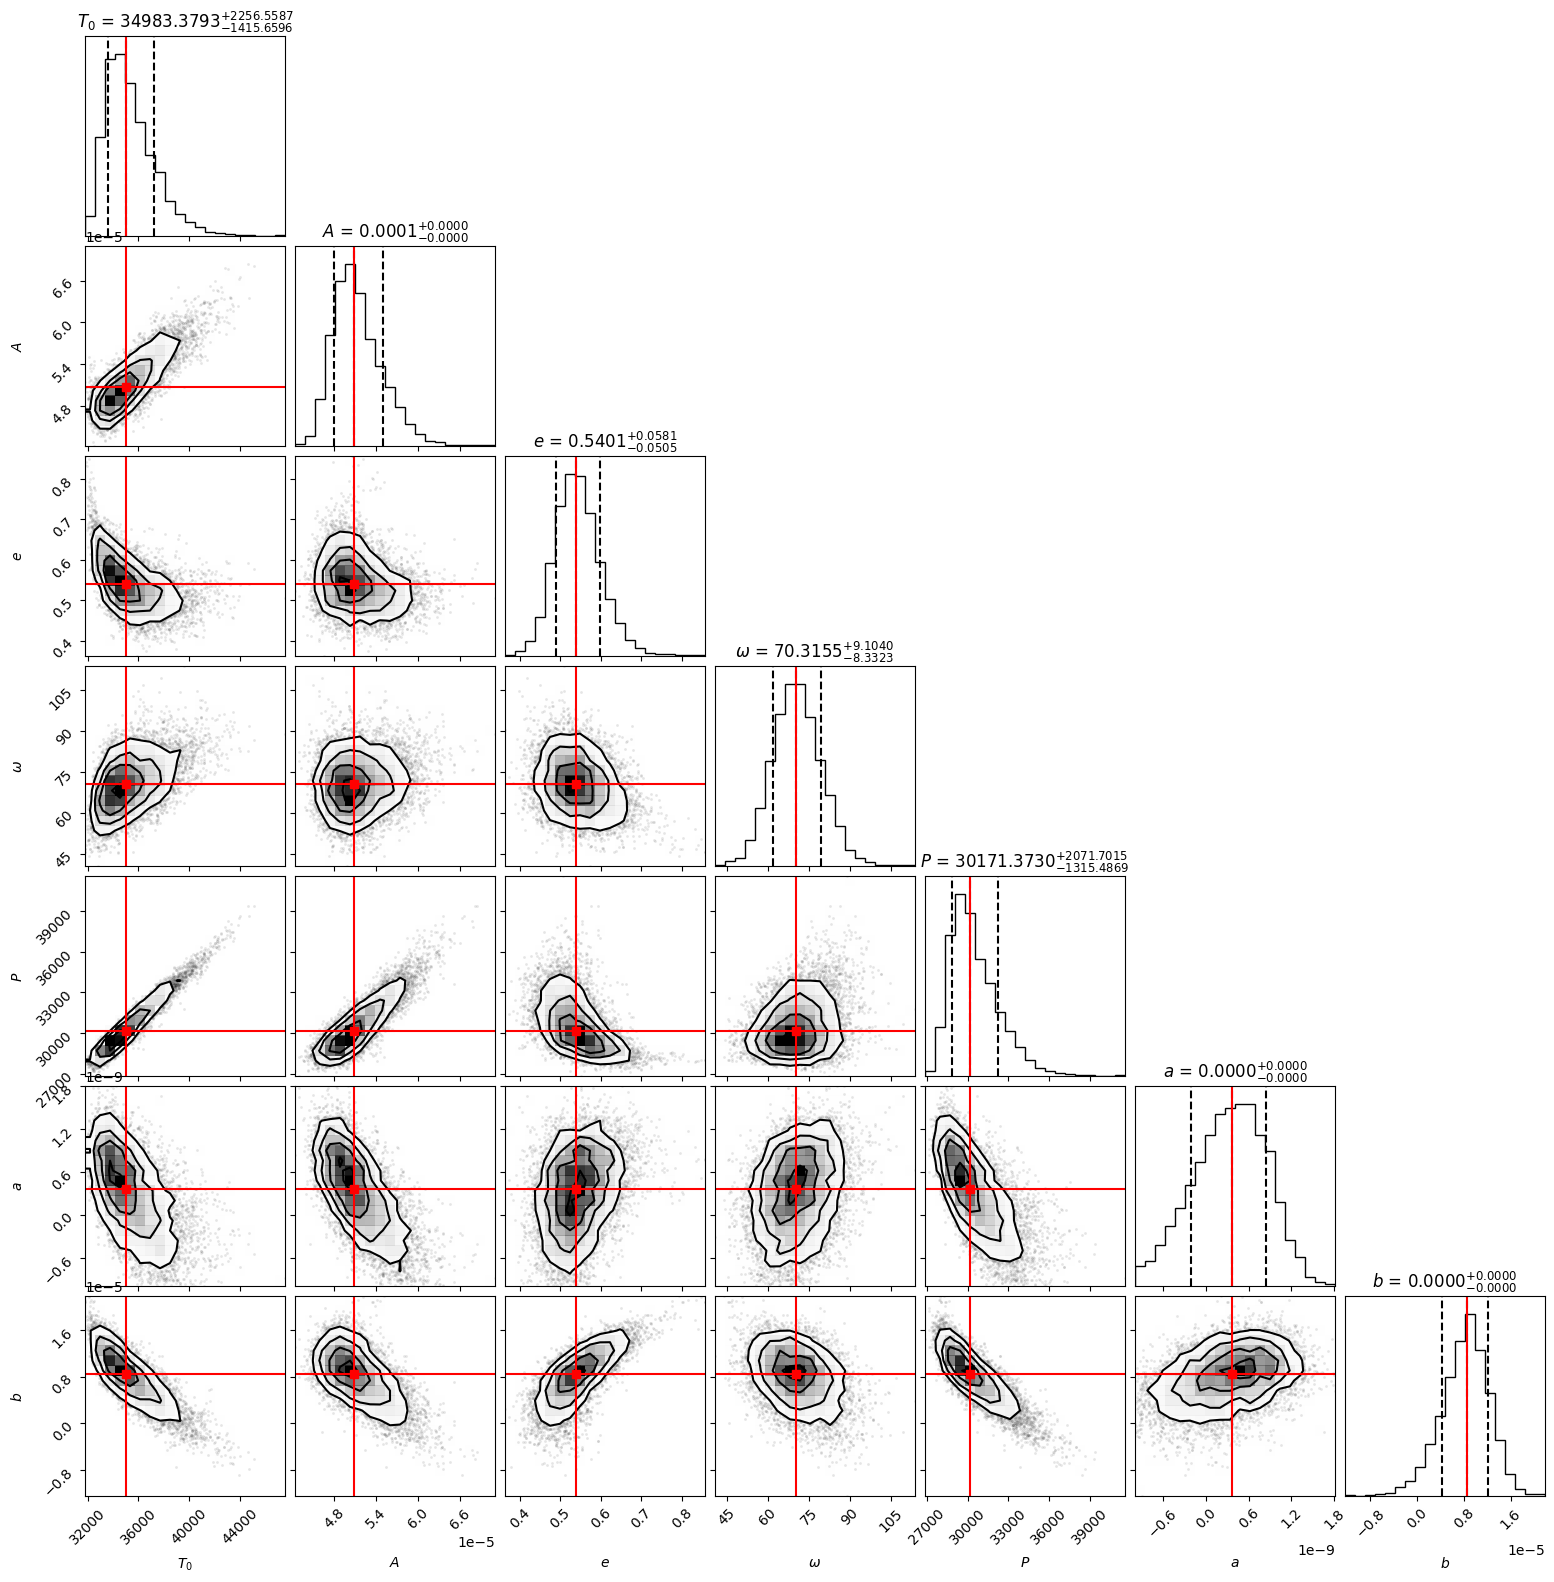

In [7]:
oc.plot(res)
oc.corner(res)

In [8]:
from ocpy.orbital_params import compute_orbital_params_from_fit
import numpy as np

# DD CrB binary masses (update with actual values)
m1 = 0.417   # primary mass (Msun)
m2 = 0.022   # secondary mass (Msun)

# Compute orbital params for each posterior sample
result = compute_orbital_params_from_fit(
    res, 
    ref_period=period,
    m1=m1, m2=m2,
)

result

Parameter,Value,Uncertainty,Unit
amp,5.0783e-05,+4.1093e−06 / −2.8023e−06,day
amp,4.387643,+0.355043 / −0.242118,s
e,0.540062,+0.058134 / −0.050474,
omega,70.315530,+9.104019 / −8.332340,deg
omega,1.227238,+0.158895 / −0.145427,rad
T_0,34983.379303,+2256.558658 / −1415.659619,BJD
P,4880.836469,+335.140078 / −212.806907,day
P,13.363287,+0.917583 / −0.582646,yr
a_{12} sin i,9.0040e-03,+6.8603e−04 / −5.2752e−04,AU
a_{12} sin i,1.936147,+0.147518 / −0.113433,R_sun
